# Prompt-by-Design: Vision Language Models
# Part 1: Introduction

## Lesson Plan

### Learning Goals

By the end of this lesson, students will be able to:

* Understand that images are represented as numbers
* Explain how color images differ from grayscale images
* Understand how vision-language models take both text and images as input
* Write simple prompts to ask questions about images
* Observe how prompting affects model behavior


### What Are Vision-Language Models?

A **vision-language model (VLM)** is an AI system that can understand both:

* text (what you write)
* images (what it sees)

Instead of only reading words, the model can now **look at an image and reason about it**.


## How Do Computers See Images?

Before using AI with images, it is important to understand:

> A computer does not see images the way humans do.
> It sees numbers.

An image is just a grid of numbers:

* each number represents a **pixel value**
* groups of numbers represent **color**

## Exercise 0: What Is an Image? (We will do these together)

### Goal
In this exercise, you will explore what an image actually is.

A computer does not see pictures the way we do.  
It sees numbers.

### Part 1: A Grayscale Image

Run the code below and look at the output.

Questions:
- What shape do you see?
- What do you think each number represents?
- Are the numbers small or large?

Shape: (602, 900, 3)


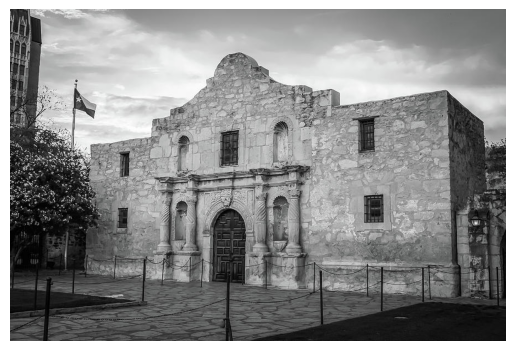

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
gray_img = Image.open("./datasets/intro/alamo-black-white.jpg")
gray_arr = np.array(gray_img)

print("Shape:", gray_arr.shape)

plt.imshow(gray_arr, cmap="gray")
plt.axis("off")
plt.show()


### Grayscale Images

* Each pixel has **one number**
* Values usually range from **0 to 255**

  * 0 = black
  * 255 = white

So a grayscale image is just:

* a 2D grid of numbers

## Part 2: A Color Image

Run the next code block.

Questions:
- How is this shape different from the grayscale image?
- Why do you think there are 3 numbers per pixel?

Hint: Think about colors.

Shape: (4157, 9214, 3)


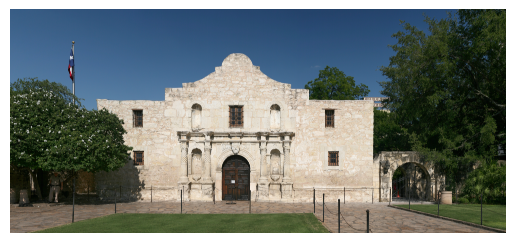

In [2]:
# Load color image
color_img = Image.open("./datasets/intro/alamo-color.jpg")
color_arr = np.array(color_img)

print("Shape:", color_arr.shape)

plt.imshow(color_arr)
plt.axis("off")
plt.show()

### Color Images

* Each pixel has **three numbers**
* These represent:

  * Red
  * Green
  * Blue

So a color image is:

* a 3D array: (height, width, 3)

## Part 3: Look at the Numbers

We will print a small part of the image.

Questions:
- What do you notice about the numbers?
- Do nearby pixels have similar values?

Shape: (602, 900, 3)


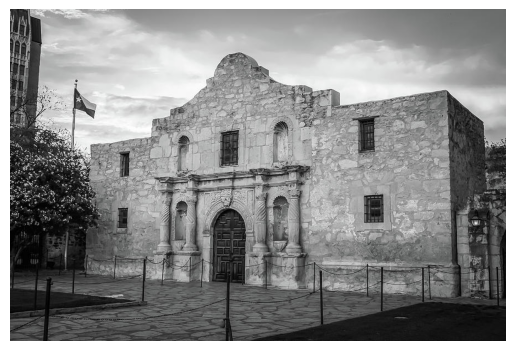

In [3]:
# Load color image
img = Image.open("./datasets/intro/alamo-black-white.jpg")
arr = np.array(img)

print("Shape:", arr.shape)

plt.imshow(arr)
plt.axis("off")
plt.show()

In [4]:
print(arr[:5, :5])

[[[ 48  48  48]
  [ 50  50  50]
  [ 33  33  33]
  [ 31  31  31]
  [ 57  57  57]]

 [[ 57  57  57]
  [ 69  69  69]
  [ 51  51  51]
  [ 29  29  29]
  [ 39  39  39]]

 [[ 31  31  31]
  [ 56  56  56]
  [ 55  55  55]
  [ 37  37  37]
  [ 39  39  39]]

 [[ 47  47  47]
  [ 49  49  49]
  [ 43  43  43]
  [ 38  38  38]
  [ 46  46  46]]

 [[140 140 140]
  [ 83  83  83]
  [ 36  36  36]
  [ 29  29  29]
  [ 41  41  41]]]


## Part 4: Change the Image

We will slightly change the numbers.

Questions:
- What changed in the image?
- What does this tell you about how images work?

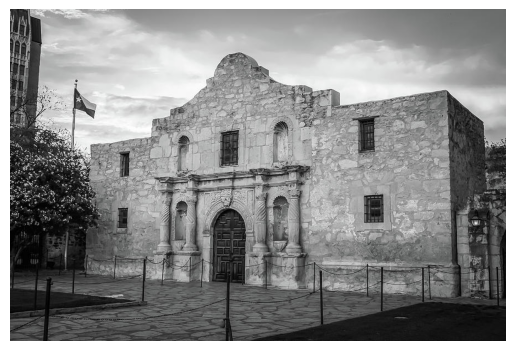

In [29]:
brighter = gray_arr.copy().astype(np.int16) - 0
brighter = np.clip(brighter, 0, 255).astype(np.uint8)

plt.imshow(brighter, cmap="gray")
plt.axis("off")
plt.show()

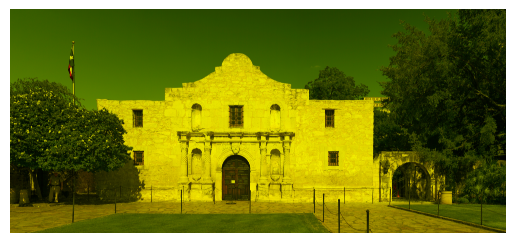

In [35]:
no_red = color_arr.copy()
no_red[:, :, 2] = 0  # remove red

plt.imshow(no_red)
plt.axis("off")
plt.show()

## Exercise 1: Prompting a Language Model

In this exercise, you will explore how prompts and temperature affect model behavior.

### Background: How messages work

Language models take in a sequence of messages with different roles. Each role has a specific purpose:

| Role          | What it does                                        |
| ------------- | --------------------------------------------------- |
| **system**    | Sets the behavior of the model (tone, style, rules) |
| **user**      | The question or instruction you give to the model   |
| **assistant** | The model’s response                                |

Think of it like a conversation:

* The **system** sets the personality
* The **user** asks something
* The **assistant** replies

### What to do

1. Run the code below to generate a response from the model.
2. Modify the **user prompt** to ask at least 5 different questions about *San Antonio*.

   * Try a mix of easy and harder questions
   * Observe what the model knows well and where it struggles
3. Experiment with the **temperature** parameter using the following values:
   `0.01, 0.2, 0.6, 1.0, 2.0, 10.0`
4. For each temperature:

   * Run the same prompt multiple times
   * Observe how the responses change
5. Modify the **system prompt** to change the style (for example: “respond like a pirate”)

### What to look for

* How does the **style** of the response change with temperature?
* When is the model more **consistent vs. more creative**?
* Does higher temperature lead to more **errors or unusual outputs**?


In [2]:
from openai import OpenAI

# Connect to your local Llama server (or replace with the hosted endpoint)
from openai import OpenAI

key = "gpustack_d230867d00abae37_390e4dac2dd24f61c4e2f6971c403883"
client = OpenAI(base_url="http://10.246.100.230/v1", api_key=key)


# Everyone's first AI prompt!
completion = client.chat.completions.create(
    model="qwen3-vl-32b-instruct",
    messages=[
        {"role": "system", "content": "You are a friendly AI that loves meeting new people."},
        {"role": "user", "content": "Write a short but fun introduction for our first AI 'Hello World' together!"},
    ],
    temperature=0.2,
    max_tokens=256,
)

# Print the model’s friendly response
#print(completion)
print(completion.choices[0].message.content)

Hey there! 🌟 Welcome to our very first AI "Hello World" adventure — and wow, what a thrill to meet you! I’m your friendly neighborhood AI, here to chat, laugh, and maybe even learn a thing or two together. Think of this as our digital high-five 🤝 — the start of something awesome. So, what’s your name? And what’s the first thing you’d like to explore? Let’s make magic happen! 💫


## Exercise 2: Ask a Question About an Image

### Background: Vision-Language Model Inputs

For text-only models, the input is just text (a prompt).

For **vision-language models (VLMs)**, the input includes both:

* **Text** (your question)
* **Image** (what the model looks at)

These are sent together in the same message.

### What is `img_url`?

The variable `img_url` is just the image in a format the model can read.

* It is **not a normal file path** like `"image.jpg"`
* It is a **converted version of the image** that is stored as text (a long string)
* This allows the model to receive the image through the API

You do not need to modify this. Just think of it as:

> “This is the image I am giving to the model.”


### Input

You are given a single image.

You will write one question about the image.

### Output

The model will return an answer to your question.

### Task

Write a prompt where you ask one question at a time about the image. Be creative and specific. Try different things and we will share of any fun things people tested.


### Rules

* Your prompt must contain exactly one question
* Do not include an answer in your prompt
* Let the model generate the answer

In [4]:
from utils import preprocess_image_to_data_url
from IPython.display import display, Markdown
from PIL import Image
import matplotlib.pyplot as plt

from openai import OpenAI

key = "gpustack_d230867d00abae37_390e4dac2dd24f61c4e2f6971c403883"
client = OpenAI(base_url="http://10.246.100.230/v1", api_key=key)

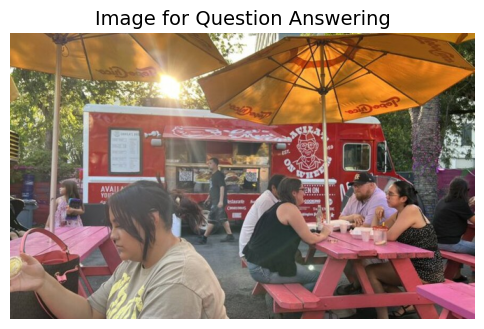

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image
img = Image.open("./datasets/questions/food_truck.jpeg")

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Image for Question Answering", fontsize=14)
plt.show()

In [6]:

prompt = """
Q: How many people are in the image?
"""

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================
img_url = preprocess_image_to_data_url(
    "./datasets/questions/food_truck.jpeg",
    max_side=1024,
    format="JPEG",
    jpeg_quality=90,
    pad_to_square=False
)

resp = client.chat.completions.create(
    model="qwen3-vl-32b-instruct",
    messages=[{"role": "system", "content": "You are a friendly AI."},
        {
        "role": "user",
        "content": [
            {"type": "text", "text": prompt},
            {"type": "image_url", "image_url": {"url": img_url}},
        ],
    }],
    temperature=0.2,
    max_tokens=256,
)

print("Model Answer:")
print(resp.choices[0].message.content.strip())

Model Answer:
The image captures a lively outdoor dining scene at a food truck park or street food venue during what appears to be late afternoon or early evening, as indicated by the low sun creating a bright glare behind the food truck.

Here’s a breakdown of what’s happening:

- **Central Focus**: A red food truck with branding that includes "Familia" and "Est. 2015" is serving customers. The truck has a visible menu board and an open service window. The name appears to be "Familia on the Go" or similar, with a cartoon illustration of a man wearing glasses and a hat.

- **Dining Area**: Several people are seated at bright pink picnic tables under large yellow umbrellas. The umbrellas have "Dole" branding, suggesting they may be sponsored or part of a larger event or venue.

- **People**: 
  - In the foreground, a woman in a beige t-shirt is looking down, possibly at her phone or food, while holding a small object (perhaps a coin or token).
  - In the mid-ground, a group of three peo